# Занятие 27. Логистическая регрессия

**Цель занятия:** научиться предсказывать **класс** и **вероятность** с помощью **логистической регрессии**,
> читать матрицу ошибок и выбирать метрику по цене **FP** / **FN**,
> настраивать **порог**, регуляризацию и веса классов на **validation**.

**Что будет:**
1. **Классификация и вероятность** — логит, сигмоида, порог → класс;
2. **sklearn** — `LogisticRegression`, `predict` / `predict_proba`, функция потерь;
3. **Честная проверка** — train / validation / test, baseline, дисбаланс и accuracy;
4. **Ошибки и порог** — confusion matrix, recall / precision, ROC и PR;
5. **Усиление модели** — масштабирование, `C`, веса классов, границы применимости, калибровка.

> **Звёздочка в заголовке.** Разделы с `*` — повышенной сложности: можно пройти по диагонали при первом чтении.


## 1. Задача классификации

В **обучении с учителем** у каждого учебного объекта есть правильный ответ. Если ответ является категорией, решается задача **классификации**.

| Признаки объекта | Ответ |
|---|---|
| текст письма, отправитель | спам / не спам |
| результаты обследования | заболевание есть / нет |
| изображение животного | кошка / собака / птица |

- Два возможных класса — **бинарная классификация**.
- Три и более — **многоклассовая классификация**.

Классы часто кодируют числами 0 и 1, но это именно метки, а не обычные числовые величины: между классами 0 и 1 нет «половины класса».

Сравним три знакомых типа задач:

| Задача | Есть правильные ответы? | Что ищем? |
|---|---|---|
| кластеризация | нет | группы похожих объектов |
| регрессия | да | число |
| классификация | да | категорию |

**Сквозной пример:** часы подготовки и сдача экзамена (0 — не сдал, 1 — сдал):

| часы подготовки | сдал экзамен |
|-----------------|--------------|
| 1.0 | 0 |
| 2.0 | 0 |
| 2.5 | 0 |
| 3.0 | 0 |
| 4.0 | 0 |
| 5.0 | 1 |
| 6.0 | 1 |
| 6.5 | 0 |
| 7.5 | 1 |
| 8.0 | 1 |


In [1]:
import numpy as np
import matplotlib.pyplot as plt

hours = np.array([1, 2, 2.5, 3, 4, 5, 6, 6.5, 7.5, 8], dtype=float)
passed = np.array([0, 0, 0, 0, 0, 1, 1, 0, 1, 1])


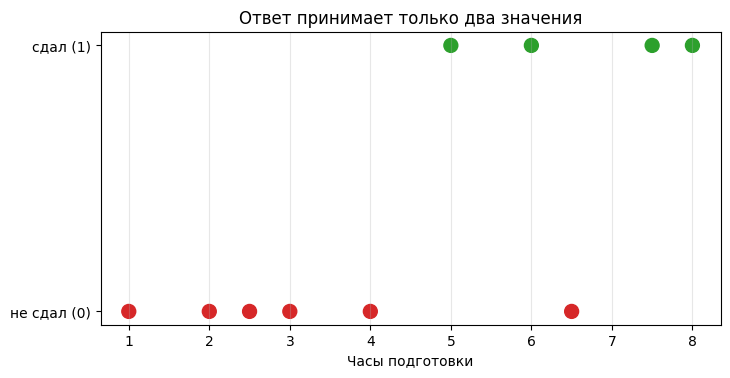


## 2. Классы и вероятности

Мы не можем точно определить, к какому классу принадлежит тот или иной объект, поэтому мы хотим предсказывать *вероятность* $p$ принадлежности 
объекта к классу 1 (в случае бинарной классификации). Вероятность - это число от 0 до 1. В алгоритме линейной регрессии мы умеем предсказывать число от -∞ до +∞.

Можно провести через нули и единицы прямую линейной регрессии, но у неё возникают проблемы:

- прогноз может оказаться меньше 0 или больше 1;
- прямая не обязана вести себя как вероятность;
- выход прямой нельзя напрямую интерпретировать как степень уверенности модели.

Нам нужна модель, которая выдаёт число строго между 0 и 1.


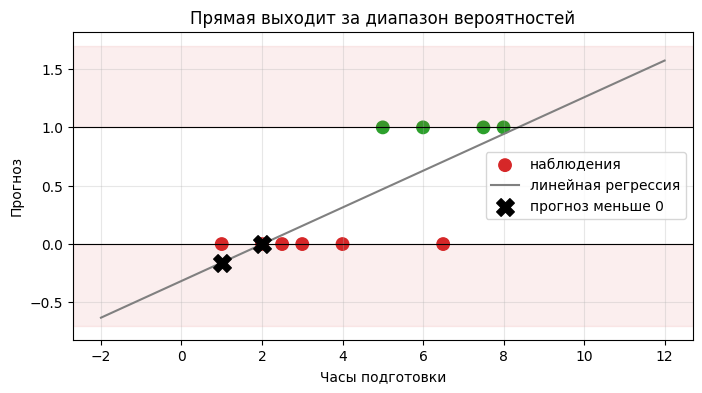

Прогноз прямой в реальных точках данных:
   1.0 ч -> -0.159  <- вероятность не может быть отрицательной!
   2.0 ч -> -0.001  <- вероятность не может быть отрицательной!
   2.5 ч -> +0.077
   3.0 ч -> +0.156
   4.0 ч -> +0.313
   5.0 ч -> +0.471
   6.0 ч -> +0.628
   6.5 ч -> +0.707
   7.5 ч -> +0.864
   8.0 ч -> +0.943


In [3]:
from sklearn.linear_model import LinearRegression

linear_classifier = LinearRegression().fit(hours.reshape(-1, 1), passed)
grid_1d = np.linspace(-2, 12, 200).reshape(-1, 1)
pred_at_data = linear_classifier.predict(hours.reshape(-1, 1))

plt.figure(figsize=(8, 4))
plt.scatter(hours, passed, c=np.where(passed == 1, 'tab:green', 'tab:red'), s=80, label='наблюдения')
plt.plot(grid_1d, linear_classifier.predict(grid_1d), color='gray', label='линейная регрессия')
plt.axhspan(-0.7, 0, color='tab:red', alpha=0.08)
plt.axhspan(1, 1.7, color='tab:red', alpha=0.08)
plt.axhline(0, color='black', linewidth=0.8)
plt.axhline(1, color='black', linewidth=0.8)
plt.scatter(hours[pred_at_data < 0], pred_at_data[pred_at_data < 0],
            marker='X', s=160, color='black', zorder=4, label='прогноз меньше 0')
plt.xlabel('Часы подготовки'); plt.ylabel('Прогноз')
plt.title('Прямая выходит за диапазон вероятностей')
plt.grid(alpha=0.3); plt.legend(); plt.show()

print('Прогноз прямой в реальных точках данных:')
for h, pr in zip(hours, pred_at_data):
    flag = '  <- вероятность не может быть отрицательной!' if pr < 0 else ''
    print(f'  {h:>4} ч -> {pr:+.3f}{flag}')


## 3. Логит и сигмоида

Покажем сначала, как можно преобразовать вероятность (число от 0 до 1) в число от -∞ до +∞. А затем воспользуемся обратной функцией, чтобы преобразовывать прогноз модели в вероятность.

Сначала преобразуем вероятность в *шансы*. Вы все слышали выражение "шансы Спартака на победу - два к одному". Это означает, что вероятность его победы 2/3. Формально, шансы (odds) это отношение вероятности победы к вероятности поражения: $odds=\frac{p}{1-p}$. Это число принимает значения от 0 (когда p=0) до +∞ (когда p=1).
Теперь преобразуем шансы в число от -∞ до +∞: для этого достаточно воспользоваться **логарифмом**.

> Всюду в этом занятии $\log$ и $\ln$ — это **одно и то же**: натуральный логарифм, то есть логарифм по основанию $e \approx 2{,}718$. В коде ему соответствует `np.log`.


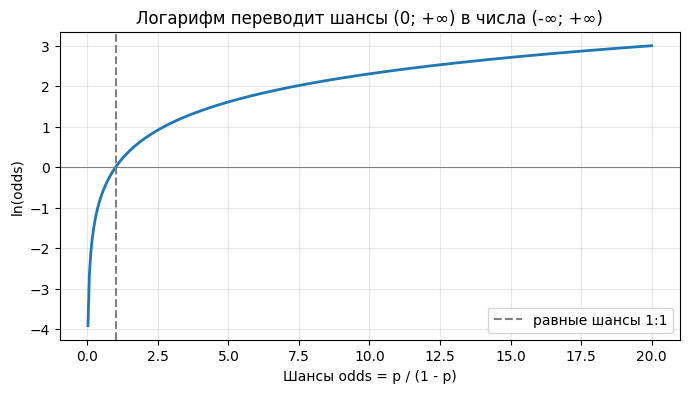


Получившаяся функция (логарифм шансов) называется **логит** (logit — от *log*istic *unit*, «логистическая единица»):
$$
logit(p)=\ln\frac{p}{1-p}.
$$

Несложно вычислить обратную функцию (её называют *сигмоидой*):
$$
p = \sigma(z)=\frac{e^z}{e^z+1}=\frac{1}{1+e^{-z}}.
$$


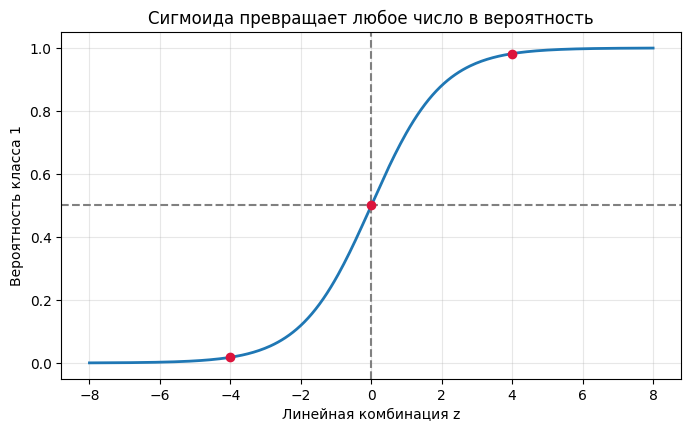


Теперь вернёмся к нашей задаче — определению вероятности того, что объект принадлежит классу 1, по его признакам $x_1,\dots,x_p$. Решать её мы будем так.

Сначала модель считает знакомую **линейную комбинацию признаков**:

$$z=w_1x_1+w_2x_2+\ldots+w_px_p+b.$$

Линейная комбинация может быть любым числом. Его называют *логит*, поскольку он равен $logit(p)$. Чтобы получить оценку вероятности класса 1, применяется **сигмоида**, обратная функция к функции $logit$:

$$P(y=1)=\sigma(z)=\frac{1}{1+e^{-z}}.$$

- при большом отрицательном $z$ вероятность близка к 0;
- при $z=0$ вероятность равна 0,5;
- при большом положительном $z$ вероятность близка к 1.

Значение $z$ остаётся линейной комбинацией признаков, хотя график оценки вероятности имеет форму буквы S.


## 4. Вероятность, порог и класс

Как перейти от вероятности к прогнозу класса?

1. Модель вычисляет вероятность $p$ класса 1.
2. Мы выбираем **порог** (threshold) $t$.
3. Если $p\ge t$, прогнозируем класс 1, иначе класс 0.

Часто начинают с порога 0,5. Тогда граница решений соответствует $p=0{,}5$, то есть $z=0$.

Порог — решение пользователя модели. Его можно изменить без повторного обучения.


In [6]:
probabilities = np.array([0.12, 0.43, 0.51, 0.78, 0.96])
print(f'{"P(класс 1)":>11} {"порог 0,5":>11} {"порог 0,8":>11}')
for prob in probabilities:
    print(f'{prob:>11.2f} {int(prob >= 0.5):>11} {int(prob >= 0.8):>11}')
print('\nМодель не переобучалась: изменился только порог, а вероятности те же.')
print('Объект с вероятностью 0,51 при пороге 0,8 переезжает из класса 1 в класс 0.')


 P(класс 1)   порог 0,5   порог 0,8
       0.12           0           0
       0.43           0           0
       0.51           1           0
       0.78           1           0
       0.96           1           1

Модель не переобучалась: изменился только порог, а вероятности те же.
Объект с вероятностью 0,51 при пороге 0,8 переезжает из класса 1 в класс 0.


## 5. Логистическая регрессия в sklearn

`LogisticRegression` подбирает коэффициенты линейной комбинации. Основные методы:

- `fit(X, y)` — обучить модель;
- `decision_function(X)` — получить значение линейной комбинации $z$;
- `predict_proba(X)` — получить оценки вероятностей классов; порядок столбцов ответа хранится в `classes_` (при обучении алгоритм сам находит все уникальные классы);
- `predict(X)` — получить итоговые классы с порогом 0,5.

Несмотря на слово «регрессия» в названии, это алгоритм **классификации**.


In [7]:
import pandas as pd
from sklearn.linear_model import LogisticRegression

X_one = hours.reshape(-1, 1)
logistic = LogisticRegression().fit(X_one, passed)

examples = np.array([[3], [5], [8]])
result = pd.DataFrame({
    'часы': examples.ravel(),
    'линейная комбинация z': logistic.decision_function(examples),
    'P(не сдал)': logistic.predict_proba(examples)[:, 0],
    'P(сдал)': logistic.predict_proba(examples)[:, 1],
    'класс': logistic.predict(examples),
})
print('Порядок классов в столбцах predict_proba:', logistic.classes_)
result.round(3)


Порядок классов в столбцах predict_proba: [0 1]


,часы,линейная комбинация z,P(не сдал),P(сдал),класс
0,3,-2.063,0.887,0.113,0
1,5,-0.355,0.588,0.412,0
2,8,2.206,0.099,0.901,1


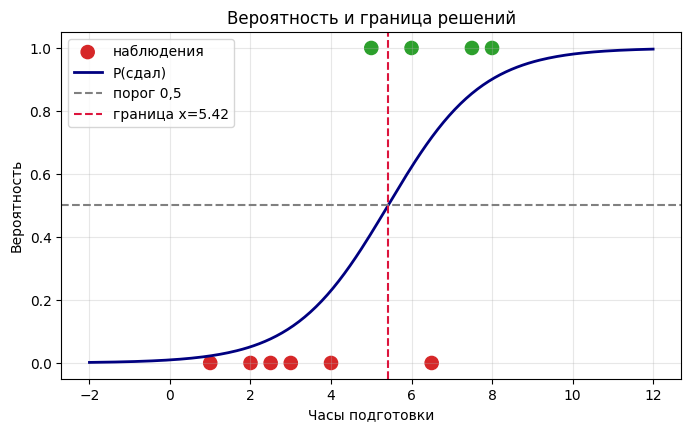

In [8]:
prob_grid = logistic.predict_proba(grid_1d)[:, 1]
boundary = -logistic.intercept_[0] / logistic.coef_[0, 0]

plt.figure(figsize=(8, 4.5))
plt.scatter(hours, passed, c=np.where(passed == 1, 'tab:green', 'tab:red'), s=90, label='наблюдения')
plt.plot(grid_1d, prob_grid, color='navy', linewidth=2, label='P(сдал)')
plt.axhline(0.5, color='gray', linestyle='--', label='порог 0,5')
plt.axvline(boundary, color='crimson', linestyle='--', label=f'граница x={boundary:.2f}')
plt.xlabel('Часы подготовки'); plt.ylabel('Вероятность')
plt.title('Вероятность и граница решений')
plt.ylim(-0.05, 1.05); plt.grid(alpha=0.3); plt.legend(); plt.show()


## 6. Как обучается модель: функция потерь *

Чтобы модель могла чему-то учиться, нужно уметь измерять, насколько плох её ответ. Такую меру называют **функцией потерь** (loss function) — чем больше её значение, тем хуже прогноз.

Рассмотрим один прогноз. Если правильный класс $y_i=1$, а мы предсказали вероятность этого класса как $p$, то добавим в штраф $-\ln p$. Почему так: раз $p \le 1$, то $\ln p \le 0$, и минус перед ним делает штраф неотрицательным.

Идея проста:

- правильный уверенный прогноз получает маленький штраф;
- неуверенный прогноз получает средний штраф;
- уверенный неправильный прогноз получает очень большой штраф.

Если же правильный класс $y_i=0$, то добавим в штраф $-\ln(1-p)$: теперь «плохо» — это большое $p$.


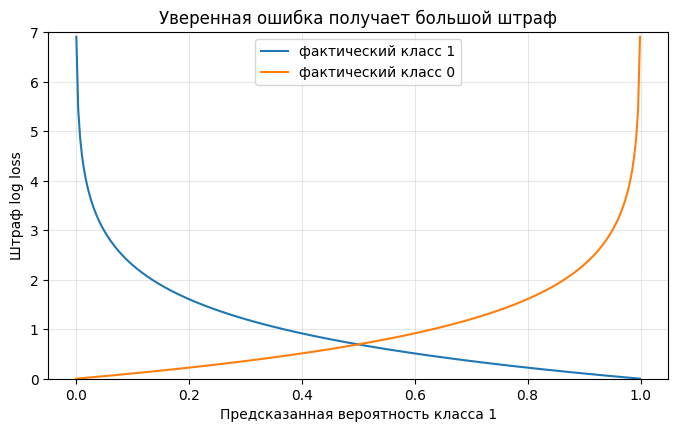



Вместе этот штраф можно записать так: $-(y_i\ln p_i+(1-y_i)\ln(1-p_i))$ (коэффициент перед одним из слагаемых в любом случае будет равен 0, а перед вторым - 1). 

Получившуюся функцию потерь называют **логарифмическая функция потерь** (*log loss*). У неё есть второе имя — **бинарная кросс-энтропия**: слово «бинарная» здесь значит «для двух классов», а «кросс-энтропия» — принятое в теории информации название для меры расхождения между тем, что модель предсказала, и тем, что случилось на самом деле. Это ровно та же формула, просто под другим именем.

$$L=-\frac1n\sum_{i=1}^n\left[y_i\ln p_i+(1-y_i)\ln(1-p_i)\right].$$

`LogisticRegression` из sklearn по умолчанию минимизирует не просто log loss, а сразу добавляет к нему **L2-штраф** за большие коэффициенты. Напомним из занятия 25: L2 — это штраф вида $\sum w_j^2$, он не даёт весам разрастаться и тем самым мешает модели переобучиться. Силой штрафа управляет параметр `C`; подробнее — в разделе 19.

Минимум ищется **итеративно**: не по готовой формуле, а много раз понемногу улучшая коэффициенты. Знакомый градиентный спуск — простейший такой способ: посчитать направление роста функции и сделать шаг в противоположную сторону. Какой именно алгоритм используется, задаёт параметр `solver`; по умолчанию это `'lbfgs'` — более быстрый родственник градиентного спуска, который сам подбирает длину шага.


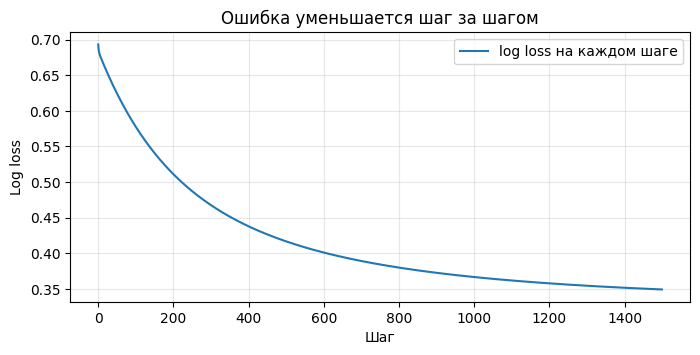

log loss в начале: 0.6931
log loss в конце:  0.3491
наши коэффициенты после 1500 шагов: w=0.794, b=-4.163
что нашёл sklearn (штраф почти выключен): w=1.134, b=-6.114

Мы идём в ту же сторону, но за 1500 шагов ещё не дошли до конца:
lbfgs внутри sklearn делает это быстрее и точнее.


In [10]:
# Покажем общую идею итеративной оптимизации на простом градиентном спуске.
w_gd, b_gd = 0.0, 0.0
learning_rate = 0.05
loss_history = []
for step in range(1500):
    z = w_gd * hours + b_gd
    p_gd = sigmoid(z)
    eps = 1e-12
    loss = -np.mean(passed * np.log(p_gd + eps) + (1 - passed) * np.log(1 - p_gd + eps))
    loss_history.append(loss)
    w_gd -= learning_rate * np.mean((p_gd - passed) * hours)
    b_gd -= learning_rate * np.mean(p_gd - passed)

plt.figure(figsize=(8, 3.5))
plt.plot(loss_history, label='log loss на каждом шаге')
plt.xlabel('Шаг'); plt.ylabel('Log loss')
plt.title('Ошибка уменьшается шаг за шагом')
plt.grid(alpha=0.3); plt.legend(); plt.show()

print(f'log loss в начале: {loss_history[0]:.4f}')
print(f'log loss в конце:  {loss_history[-1]:.4f}')
print(f'наши коэффициенты после 1500 шагов: w={w_gd:.3f}, b={b_gd:.3f}')

reference = LogisticRegression(C=10_000).fit(hours.reshape(-1, 1), passed)
print(f'что нашёл sklearn (штраф почти выключен): w={reference.coef_[0, 0]:.3f}, '
      f'b={reference.intercept_[0]:.3f}')
print('\nМы идём в ту же сторону, но за 1500 шагов ещё не дошли до конца:')
print('lbfgs внутри sklearn делает это быстрее и точнее.')


## 7. Учебный пример с двумя признаками

До сих пор мы работали с одним признаком — часами подготовки. Дальше в этом блокноте будем оценивать качество модели на более крупном примере с **двумя признаками**: часами подготовки и продолжительностью сна.

Модель по-прежнему считает линейную комбинацию $z=w_1\cdot\text{подготовка}+w_2\cdot\text{сон}+b$, а затем превращает $z$ в вероятность с помощью сигмоиды. Сначала создадим данные; разделение на train, validation и test сделаем в следующем разделе — непосредственно перед оценкой качества.
Данные мы **придумаем сами**, а не возьмём настоящие. Так удобнее учиться: мы заранее знаем правило, по которому ставится ответ, и можем проверить, найдёт ли его модель. Правило будет линейным — «чем больше подготовка и сон, тем выше шанс сдать» — плюс случайный шум. Из-за этого модель дальше покажет очень высокие метрики: мы буквально дали ей задачу того типа, который она умеет решать. На настоящих данных так почти никогда не бывает.


In [11]:
rng = np.random.default_rng(42)
n = 200
study_hours = rng.uniform(0, 10, n)
sleep_hours = rng.uniform(4, 10, n)
true_score = 0.9 * study_hours + 0.55 * sleep_hours - 7.2 + rng.normal(0, 1.2, n)
y = (true_score > 0).astype(int)
X = pd.DataFrame({'подготовка': study_hours, 'сон': sleep_hours})

print(f'Объектов: {len(X)}, доля класса 1: {y.mean():.2f}')
X.head()


Объектов: 200, доля класса 1: 0.65


,подготовка,сон
0,7.739560,8.664429
1,4.388784,9.830959
2,8.585979,7.004447
3,6.973680,4.863385
4,0.941773,4.083618


## 8. Train, validation и test

Прежде чем считать метрики и подбирать порог, данные нужно **разделить**. Это тот же принцип, что на занятии 21 о рабочем процессе ML:

- **train** — обучение коэффициентов модели;
- **validation** — оценка качества и выбор порога, пока мы ещё настраиваем решение;
- **test** — одна финальная проверка уже выбранного варианта; к нему не возвращаются при настройке.

Test похож на запечатанный вариант контрольной: если после просмотра test менять модель или порог, test перестаёт быть честной проверкой. Поэтому тестовую выборку откладываем сейчас и впервые открываем только в разделе 14.

Для классификации важно сохранить примерно одинаковую долю классов во всех частях. Параметр `stratify=y` в `train_test_split` выполняет такое **стратифицированное разбиение**.

Ниже данные делятся на три части, модель обучается только на train, а прогнозы для дальнейших разделов готовятся на validation.


In [12]:
from sklearn.model_selection import train_test_split

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=42, stratify=y_train_val
)

model = LogisticRegression().fit(X_train, y_train)
y_val_pred = model.predict(X_val)

print('Доли класса 1:')
print(f'в исходных данных: {y.mean():.2f}')
print(f'в обучении:        {y_train.mean():.2f}')
print(f'в валидации:       {y_val.mean():.2f}')
print(f'в тесте:           {y_test.mean():.2f}')
print(f'\nРазмеры: train={len(y_train)}, val={len(y_val)}, test={len(y_test)}')
print('\nВыборки получились маленькие — это важно помнить:')
print(f'  одна ошибка на validation меняет accuracy на {1/len(y_val):.3f}')
print(f'  одна ошибка на test       меняет accuracy на {1/len(y_test):.3f}')
print('Поэтому разницу в метриках в пару сотых нельзя считать настоящей разницей.')


Доли класса 1:
в исходных данных: 0.65
в обучении:        0.64
в валидации:       0.66
в тесте:           0.64

Размеры: train=112, val=38, test=50

Выборки получились маленькие — это важно помнить:
  одна ошибка на validation меняет accuracy на 0.026
  одна ошибка на test       меняет accuracy на 0.020
Поэтому разницу в метриках в пару сотых нельзя считать настоящей разницей.


## 9. Матрица ошибок

**Матрица ошибок** (*confusion matrix*, дословно «матрица путаницы») — таблица, которая показывает не только сколько ошибок сделала модель, но и **какие именно**. Используем прогнозы модели на **validation** из раздела 8 — эти объекты не участвовали в обучении коэффициентов.


Для бинарной классификации каждый прогноз попадает в одну из четырёх групп:

| | Прогноз 0 | Прогноз 1 |
|---|---:|---:|
| **Факт 0** | TN — *True Negative*, верно отвергли | FP — *False Positive*, ложная тревога |
| **Факт 1** | FN — *False Negative*, пропустили | TP — *True Positive*, верно нашли |

«Положительным» называется класс 1, а не обязательно хороший исход. Например, классом 1 может быть заболевание.


TN=9, FP=4, FN=1, TP=24


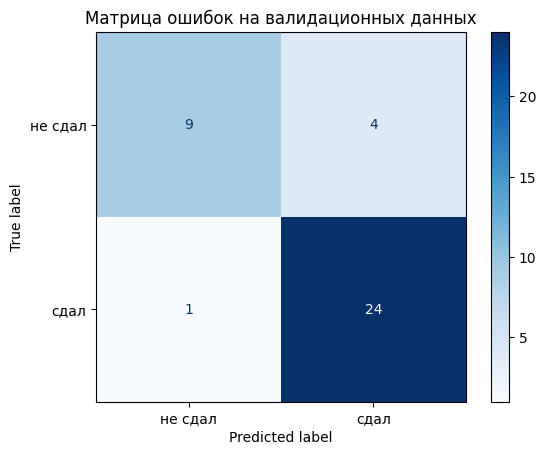

In [13]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm = confusion_matrix(y_val, y_val_pred)
tn, fp, fn, tp = cm.ravel()
print(f'TN={tn}, FP={fp}, FN={fn}, TP={tp}')

ConfusionMatrixDisplay(cm, display_labels=['не сдал', 'сдал']).plot(cmap='Blues')
plt.title('Матрица ошибок на валидационных данных')
plt.show()


## 10. Метрики классификации

$$Accuracy=\frac{TP+TN}{TP+TN+FP+FN}$$

$$Precision=\frac{TP}{TP+FP},\qquad Recall=\frac{TP}{TP+FN}$$

$$F1=\frac{2}{\frac{1}{Precision}+\frac{1}{Recall}}=2\cdot\frac{Precision\cdot Recall}{Precision+Recall}$$

- **Accuracy** (*доля правильных ответов*) — какая доля всех ответов верна.
- **Precision** (по-русски *точность*) — как часто модель права, когда говорит «класс 1».
- **Recall** (по-русски *полнота*) — какую долю настоящих объектов класса 1 модель нашла.
- **F1** — **среднее гармоническое** precision и recall. Обычное среднее двух чисел — это их полусумма; среднее гармоническое считается по формуле выше и всегда ближе к меньшему из двух. Поэтому провал по любой из двух метрик тянет F1 вниз, и модель вынуждена держать баланс.

> **Подумайте.** Можно было бы вместо F1 брать просто минимум из precision и recall — он тоже наказывает за провал. Чем F1 удобнее? Подсказка: сравните, как поведут себя min и F1, если precision вырастет с 0,6 до 0,8, а recall останется 0,5.


Нет лучшей метрики для всех задач. Для опасного заболевания особенно дорог FN, поэтому важен recall. Для дорогой ручной проверки ложные тревоги FP могут сделать процесс бесполезным, поэтому важен precision.


In [14]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print('Метрики при начальном пороге 0,5 на validation:')
print(f'Accuracy:  {accuracy_score(y_val, y_val_pred):.3f}')
print(f'Precision: {precision_score(y_val, y_val_pred):.3f}')
print(f'Recall:    {recall_score(y_val, y_val_pred):.3f}')
print(f'F1:        {f1_score(y_val, y_val_pred):.3f}')


Метрики при начальном пороге 0,5 на validation:
Accuracy:  0.868
Precision: 0.857
Recall:    0.960
F1:        0.906


## 11. Baseline для классификации

Перед сложной моделью нужен простой соперник — **baseline**. Сравнивать модель нужно с baseline на **одних и тех же** данных.

Baseline в классификации — это «модель», которая вообще не смотрит на признаки и отвечает по простому правилу. В sklearn такие правила собраны в `DummyClassifier`:

| `strategy` | Как отвечает |
|---|---|
| `most_frequent` | всегда самым частым классом train |
| `prior` | так же, но `predict_proba` возвращает доли классов train |
| `stratified` | случайно, с вероятностями, равными долям классов train |
| `uniform` | случайно, все классы равновероятны |
| `constant` | всегда заданным классом (например, редким) |

Baseline отвечает на вопрос: «А признаки вообще помогают?» Если модель не обгоняет `DummyClassifier`, значит пользы от признаков или от самой модели нет.

Обратите внимание на подвох в выводе ниже. Самый частый класс в **train** — это как раз класс 1, поэтому `most_frequent` ставит единицу всем подряд. На **validation**, где доля класса 1 равна 0,66, у такого baseline recall получается равным 1,00: он не пропустил ни одного объекта класса 1 просто потому, что никого не отнёс к классу 0. При этом accuracy и precision у него равны той самой доле 0,66 — он угадывает ровно так часто, как часто встречается класс 1. Вывод: любую отдельную метрику можно «купить» тривиальным ответом, поэтому baseline сравнивают сразу по нескольким метрикам.


In [15]:
from sklearn.dummy import DummyClassifier

dummy_val = DummyClassifier(strategy='most_frequent').fit(X_train, y_train)

rows_baseline = []
for name, estimator in [('baseline (most_frequent)', dummy_val),
                        ('логистическая регрессия', model)]:
    pred = estimator.predict(X_val)
    rows_baseline.append({
        'модель': name,
        'accuracy': accuracy_score(y_val, pred),
        'precision': precision_score(y_val, pred, zero_division=0),
        'recall': recall_score(y_val, pred, zero_division=0),
        'F1': f1_score(y_val, pred, zero_division=0),
    })

print(f'Доля класса 1 в validation: {y_val.mean():.2f}')
pd.DataFrame(rows_baseline).round(3)


Доля класса 1 в validation: 0.66


,модель,accuracy,precision,recall,F1
0,baseline (most_frequent),0.658,0.658,1.00,0.794
1,логистическая регрессия,0.868,0.857,0.96,0.906


## 12. Дисбаланс классов: почему accuracy обманывает

Если 95% писем не являются спамом, модель «всегда не спам» получит accuracy 95%, хотя не найдёт ни одного спам-письма. Такой перекос называется **дисбалансом классов**.

В разделе 11 классы были почти поровну, и baseline честно проигрывал по всем метрикам сразу. Сейчас посмотрим, что меняется, когда класс 1 редкий. Данные снова придумаем сами: функция `make_classification` из sklearn генерирует случайную задачу классификации, а параметр `weights=[0.92, 0.08]` задаёт, что класса 1 будет всего 8%.

Смотрите на таблицу так: сравните **accuracy** baseline и модели, а потом — их **recall класса 1**. Разница в accuracy окажется маленькой, а разница в recall — огромной. Именно поэтому на несбалансированных данных accuracy не годится как главная метрика.

Правило: при дисбалансе сначала смотрят доли классов, затем выбирают метрику по цене ошибок — что дороже, пропуск (FN) или ложная тревога (FP).


In [16]:
from sklearn.datasets import make_classification

X_imb, y_imb = make_classification(
    n_samples=800, n_features=5, n_informative=3, n_redundant=0,
    weights=[0.92, 0.08], class_sep=1.0, random_state=42
)
X_imb_train, X_imb_control, y_imb_train, y_imb_control = train_test_split(
    X_imb, y_imb, test_size=0.3, random_state=42, stratify=y_imb
)

dummy = DummyClassifier(strategy='most_frequent').fit(X_imb_train, y_imb_train)
ordinary_imb = LogisticRegression(max_iter=1000).fit(X_imb_train, y_imb_train)

rows_imb = []
for name, estimator in [('baseline', dummy), ('логистическая регрессия', ordinary_imb)]:
    pred = estimator.predict(X_imb_control)
    rows_imb.append({
        'модель': name,
        'accuracy': accuracy_score(y_imb_control, pred),
        'precision класса 1': precision_score(y_imb_control, pred, zero_division=0),
        'recall класса 1': recall_score(y_imb_control, pred, zero_division=0),
        'F1 класса 1': f1_score(y_imb_control, pred, zero_division=0),
    })

print(f'Доля редкого класса 1 в контрольной выборке: {y_imb_control.mean():.3f}')
pd.DataFrame(rows_imb).round(3)


Доля редкого класса 1 в контрольной выборке: 0.083


,модель,accuracy,precision класса 1,recall класса 1,F1 класса 1
0,baseline,0.917,0.0,0.0,0.000
1,логистическая регрессия,0.983,1.0,0.8,0.889


## 13. Как порог меняет ошибки

Низкий порог чаще назначает класс 1:

- recall обычно растёт — положительные объекты труднее пропустить;
- precision может снизиться — ложных тревог становится больше.

Высокий порог действует наоборот. Порог выбирают на валидационных данных, а тест оставляют для финальной проверки.


In [17]:
p_val = model.predict_proba(X_val)[:, 1]

rows = []
for threshold in np.linspace(0.15, 0.85, 15):
    pred_t = (p_val >= threshold).astype(int)
    rows.append({
        'порог': threshold,
        'precision': precision_score(y_val, pred_t, zero_division=0),
        'recall': recall_score(y_val, pred_t, zero_division=0),
        'F1': f1_score(y_val, pred_t, zero_division=0),
        'предсказано единиц': pred_t.sum(),
    })
threshold_table = pd.DataFrame(rows)
best_threshold = threshold_table.loc[threshold_table['F1'].idxmax(), 'порог']
print(f'Лучший из проверенных порогов по F1 на validation: {best_threshold:.2f}')
threshold_table.round(3)


Лучший из проверенных порогов по F1 на validation: 0.35


,порог,precision,recall,F1,предсказано единиц
0,0.15,0.781,1.00,0.877,32
1,0.20,0.806,1.00,0.893,31
2,0.25,0.833,1.00,0.909,30
3,0.30,0.833,1.00,0.909,30
4,0.35,0.862,1.00,0.926,29
5,0.40,0.857,0.96,0.906,28
6,0.45,0.857,0.96,0.906,28
7,0.50,0.857,0.96,0.906,28
8,0.55,0.857,0.96,0.906,28
9,0.60,0.889,0.96,0.923,27


## 14. Первый честный test

Все решения приняты: модель обучена на train, порог выбран на validation, метрики выбраны. Теперь **один раз** открываем test и смотрим, что получилось. Повторные правки после просмотра test делают его оценку слишком оптимистичной — подробнее в следующей теме.

Ниже мы применяем к test **ровно тот порог**, который выбрали в разделе 13, и сравниваем метрики на validation и на test. Если бы на test было заметно хуже, это был бы сигнал, что мы подогнали порог под 38 валидационных объектов.


In [18]:
p_test = model.predict_proba(X_test)[:, 1]
y_test_pred = (p_test >= best_threshold).astype(int)
y_val_pred_t = (p_val >= best_threshold).astype(int)

print(f'Порог, выбранный на validation: {best_threshold:.2f}\n')
final_report = pd.DataFrame([
    {'выборка': 'validation',
     'accuracy': accuracy_score(y_val, y_val_pred_t),
     'precision': precision_score(y_val, y_val_pred_t, zero_division=0),
     'recall': recall_score(y_val, y_val_pred_t, zero_division=0),
     'F1': f1_score(y_val, y_val_pred_t, zero_division=0)},
    {'выборка': 'test',
     'accuracy': accuracy_score(y_test, y_test_pred),
     'precision': precision_score(y_test, y_test_pred, zero_division=0),
     'recall': recall_score(y_test, y_test_pred, zero_division=0),
     'F1': f1_score(y_test, y_test_pred, zero_division=0)},
])
print(final_report.round(3).to_string(index=False))
print(f'\nОбъектов в test всего {len(y_test)}: одна ошибка меняет accuracy на {1/len(y_test):.2f},')
print('поэтому разницу в пару сотых между validation и test считать улучшением нельзя.')


Порог, выбранный на validation: 0.35

   выборка  accuracy  precision  recall    F1
validation     0.895      0.862     1.0 0.926
      test     0.960      0.941     1.0 0.970

Объектов в test всего 50: одна ошибка меняет accuracy на 0.02,
поэтому разницу в пару сотых между validation и test считать улучшением нельзя.


## 15. ROC- и PR-кривые *

ROC и PR показывают качество **ранжирования** объектов по вероятности **без выбора одного порога**. Порог подбирают отдельно на validation (п. 13).

Метрики из п. 10 считаются уже **после** того, как порог выбран. Но модель выдаёт вероятности, и полезно проверить её до выбора порога: насколько хорошо она **ранжирует** объекты, то есть даёт настоящим объектам класса 1 более высокие вероятности, чем объектам класса 0. Для этого перебирают **все** пороги подряд и каждый порог рисуют одной точкой кривой.

**ROC-кривая** (*receiver operating characteristic* — исторический термин из радиолокации 1940-х годов, «характеристика работы приёмника»; переводить его не принято, просто запомните сокращение) по каждому порогу откладывает:

- по оси Y — **TPR** (*True Positive Rate*, доля верно найденных единиц) $=\frac{TP}{TP+FN}$. Это в точности **recall**: какую долю настоящих единиц модель поймала;
- по оси X — **FPR** (*False Positive Rate*, доля ложных тревог) $=\frac{FP}{FP+TN}$: какую долю настоящих нулей модель ошибочно назвала единицами.

Обратите внимание: обе дроби собраны из тех же TP, FP, FN, TN, что и матрица ошибок в п.9, — просто для каждого порога она своя.


Как читать: чем выше и правее, тем лучше. Уровень «случайной» модели здесь не диагональ, а горизонтальная линия на высоте доли класса 1. Площадь под кривой называют **AP** (*average precision*, «средняя точность») — одним числом она говорит, насколько высоко кривая проходит.


Чем они отличаются:

| | ROC | PR |
|---|---|---|
| оси | FPR и TPR | recall и precision |
| уровень случайной модели | диагональ, AUC = 0,5 | доля класса 1 |
| учитывает TN | да | нет |
| при сильном дисбалансе | выглядит слишком оптимистично | честнее показывает работу с редким классом |

Причина разницы в последней строке: при редком классе 1 нулей очень много, поэтому знаменатель FPR огромный, ложные тревоги почти не сдвигают ROC-кривую — и слабая модель выглядит красиво. Precision же считается только по предсказанным единицам и сразу реагирует на ложные тревоги.

На каких данных строить: пока модель настраивают — на **validation**; в финальном отчёте — **один раз** на test (п. 14). Ниже строим ROC и PR на test — уже после финального отчёта из п. 14.

Кривые не выбирают порог за нас: они оценивают модель целиком, а рабочий порог по-прежнему подбирают на validation (п. 13).


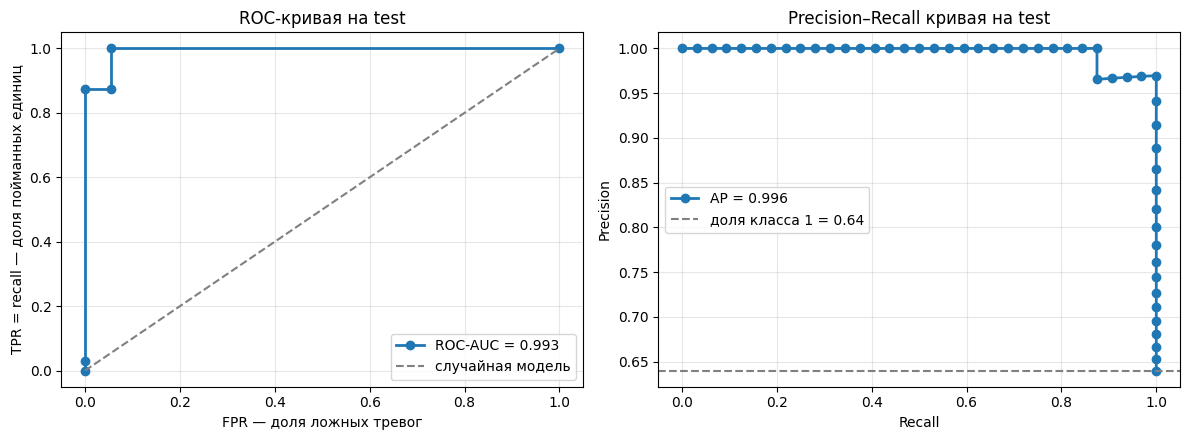

Точек-порогов на ROC-кривой всего 6: в test лишь 50 объектов,
поэтому кривая — короткая ломаная, а не плавная линия.
ROC-AUC = 0.993 — почти идеально, но помните раздел 7:
мы сами придумали данные по линейному правилу, а модель ищет именно линейное правило.


In [19]:
from sklearn.metrics import (roc_curve, roc_auc_score,
                             precision_recall_curve, average_precision_score)

fpr, tpr, _ = roc_curve(y_test, p_test)
precision_curve, recall_curve, _ = precision_recall_curve(y_test, p_test)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(fpr, tpr, marker='o', linewidth=2,
             label=f'ROC-AUC = {roc_auc_score(y_test, p_test):.3f}')
axes[0].plot([0, 1], [0, 1], '--', color='gray', label='случайная модель')
axes[0].set_xlabel('FPR — доля ложных тревог')
axes[0].set_ylabel('TPR = recall — доля пойманных единиц')
axes[0].set_title('ROC-кривая на test')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(recall_curve, precision_curve, marker='o', linewidth=2,
             label=f'AP = {average_precision_score(y_test, p_test):.3f}')
axes[1].axhline(y_test.mean(), linestyle='--', color='gray',
                label=f'доля класса 1 = {y_test.mean():.2f}')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision–Recall кривая на test')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f'Точек-порогов на ROC-кривой всего {len(fpr)}: в test лишь {len(y_test)} объектов,')
print('поэтому кривая — короткая ломаная, а не плавная линия.')
print(f'ROC-AUC = {roc_auc_score(y_test, p_test):.3f} — почти идеально, но помните раздел 7:')
print('мы сами придумали данные по линейному правилу, а модель ищет именно линейное правило.')


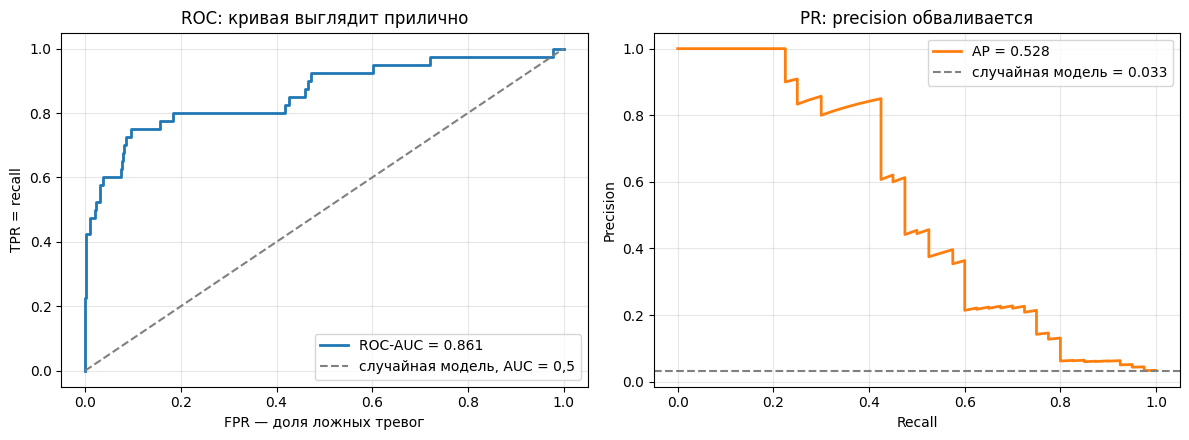

Класс 1 встречается в 3.3% случаев.
ROC-AUC = 0.861 — звучит как хорошая модель.
А теперь посмотрим, какой ценой она ловит редкий класс:
  чтобы поймать 50% редкого класса, precision падает до 0.457
  чтобы поймать 80% редкого класса, precision падает до 0.131

При recall 80% почти 9 из 10 сработок — ложная тревога.
ROC этого не показал, потому что нулей очень много и знаменатель FPR огромный.


In [20]:
# Проверим главный тезис: при редком классе ROC приукрашивает, а PR — нет.
X_rare, y_rare = make_classification(
    n_samples=4000, n_features=5, n_informative=3, n_redundant=0,
    weights=[0.97, 0.03], class_sep=0.6, flip_y=0.01, random_state=42,
)
Xr_train, Xr_control, yr_train, yr_control = train_test_split(
    X_rare, y_rare, test_size=0.3, random_state=42, stratify=y_rare
)
rare_model = LogisticRegression(max_iter=1000).fit(Xr_train, yr_train)
p_rare = rare_model.predict_proba(Xr_control)[:, 1]

share = yr_control.mean()
auc_rare = roc_auc_score(yr_control, p_rare)
ap_rare = average_precision_score(yr_control, p_rare)
fpr_r, tpr_r, _ = roc_curve(yr_control, p_rare)
prec_r, rec_r, _ = precision_recall_curve(yr_control, p_rare)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(fpr_r, tpr_r, linewidth=2, label=f'ROC-AUC = {auc_rare:.3f}')
axes[0].plot([0, 1], [0, 1], '--', color='gray', label='случайная модель, AUC = 0,5')
axes[0].set_xlabel('FPR — доля ложных тревог'); axes[0].set_ylabel('TPR = recall')
axes[0].set_title('ROC: кривая выглядит прилично')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(rec_r, prec_r, linewidth=2, color='tab:orange', label=f'AP = {ap_rare:.3f}')
axes[1].axhline(share, linestyle='--', color='gray', label=f'случайная модель = {share:.3f}')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('PR: precision обваливается')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f'Класс 1 встречается в {share:.1%} случаев.')
print(f'ROC-AUC = {auc_rare:.3f} — звучит как хорошая модель.')
print('А теперь посмотрим, какой ценой она ловит редкий класс:')
for target in [0.5, 0.8]:
    print(f'  чтобы поймать {target:.0%} редкого класса, precision падает до '
          f'{prec_r[rec_r >= target].max():.3f}')
print('\nПри recall 80% почти 9 из 10 сработок — ложная тревога.')
print('ROC этого не показал, потому что нулей очень много и знаменатель FPR огромный.')


## 16. Граница решений при нескольких признаках

Для двух признаков граница $p=0{,}5$ задаётся уравнением

$$w_1x_1+w_2x_2+b=0.$$

На плоскости это прямая. С одной стороны модель выбирает класс 0, с другой — класс 1. Это граница для стандартного порога $t=0{,}5$. При другом пороге линия сдвинется и будет задаваться уравнением

$$w_1x_1+w_2x_2+b=\ln\frac{t}{1-t}.$$

При большем числе признаков получается **гиперплоскость** — это просто общее слово для «плоского» разделителя в пространстве любой размерности: при двух признаках это прямая, при трёх — обычная плоскость, при четырёх и больше нарисовать её уже нельзя, но формула $w_1x_1+\ldots+w_px_p+b=0$ остаётся той же.


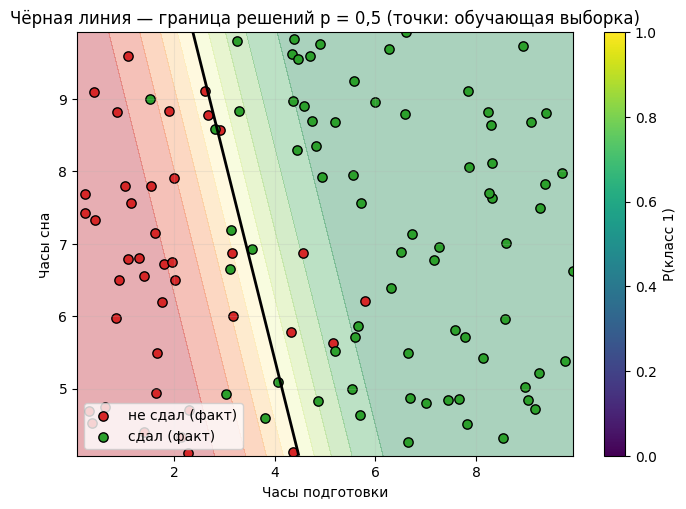

In [21]:
x1 = np.linspace(X['подготовка'].min(), X['подготовка'].max(), 160)
x2 = np.linspace(X['сон'].min(), X['сон'].max(), 160)
xx1, xx2 = np.meshgrid(x1, x2)
grid_2d = pd.DataFrame({'подготовка': xx1.ravel(), 'сон': xx2.ravel()})
surface = model.predict_proba(grid_2d)[:, 1].reshape(xx1.shape)

plt.figure(figsize=(8, 5.5))
plt.contourf(xx1, xx2, surface, levels=np.linspace(0, 1, 11), cmap='RdYlGn', alpha=0.35)
plt.contour(xx1, xx2, surface, levels=[0.5], colors='black', linewidths=2)
for label, colour, name in [(0, 'tab:red', 'не сдал (факт)'), (1, 'tab:green', 'сдал (факт)')]:
    mask = (y_train == label)
    plt.scatter(X_train['подготовка'][mask], X_train['сон'][mask],
                c=colour, edgecolor='black', s=45, label=name)
plt.colorbar(label='P(класс 1)')
plt.xlabel('Часы подготовки'); plt.ylabel('Часы сна')
plt.title('Чёрная линия — граница решений p = 0,5 (точки: обучающая выборка)')
plt.grid(alpha=0.2); plt.legend(loc='lower left'); plt.show()


## 17. Как интерпретировать коэффициенты *

Знак коэффициента показывает направление связи при неизменных остальных признаках:

- $w_j>0$ — с ростом признака и фиксированных остальных признаках вероятность класса 1 растёт;
- $w_j<0$ — при тех же условиях уменьшается.

Чем больше модуль коэффициента, тем сильнее признак влияет на значение $z$. Однако сравнивать величины коэффициентов можно только у признаков одного масштаба. Например, коэффициенты температуры в градусах и тысячных долях градуса будут разными, хотя смысл признака одинаков.

А что коэффициент означает **точно**? Вспомним п.3: модель считает $z=\log(\text{шансы})$. Значит, если признак $x_j$ вырос на единицу, то $z$ вырос на $w_j$, а шансы **умножились** на $e^{w_j}$. Это и есть точная формулировка:

$$\text{новые шансы} = \text{старые шансы}\cdot e^{w_j}.$$

Величину $e^{w_j}$ называют **отношением шансов** (*odds ratio*). Если $e^{w_j}=2$, то каждый дополнительный час подготовки удваивает шансы сдать.

Один и тот же прирост $z$ по-разному меняет вероятность около 0,5 и около 0 или 1. Поэтому нельзя сказать, что увеличение признака на единицу всегда добавляет к вероятности один и тот же процент. 

**Коэффициенты описывают связь в данных, а не доказывают причину.**


In [22]:
coef_table = pd.DataFrame({
    'признак': X.columns,
    'коэффициент w': model.coef_[0],
    'во сколько раз растут шансы, exp(w)': np.exp(model.coef_[0]),
})
print(f'Свободный член b = {model.intercept_[0]:.3f}')
print('Читаем так: +1 час подготовки умножает шансы сдать примерно на '
      f'{np.exp(model.coef_[0][0]):.1f}, а +1 час сна — примерно на '
      f'{np.exp(model.coef_[0][1]):.1f}.')
print('Оба признака помогают, но подготовка — заметно сильнее.')
coef_table.round(3)


Свободный член b = -7.805
Читаем так: +1 час подготовки умножает шансы сдать примерно на 3.7, а +1 час сна — примерно на 1.6.
Оба признака помогают, но подготовка — заметно сильнее.


,признак,коэффициент w,"во сколько раз растут шансы, exp(w)"
0,подготовка,1.313,3.718
1,сон,0.472,1.604


## 18. Зачем масштабировать перед L1/L2

Признаки в разных единицах измерения по-разному попадают под штраф регуляризации. Перед Ridge/Lasso/ElasticNet числовые признаки обычно масштабируют (`StandardScaler`, `fit` только на train).

Проверим, что будет, если этого не сделать. Запишем ту же подготовку не в часах, а в сутках: 5 часов превратятся в 0,21. Сами данные не изменились, изменилась только единица измерения.


> Напоминание из занятия 25: **`StandardScaler`** вычитает из каждого признака его среднее и делит на стандартное отклонение. После этого у всех признаков среднее 0 и разброс 1 — они становятся сравнимыми, и единицы измерения перестают влиять. Обучать (`fit`) его нужно **только на train**, иначе информация из validation и test просочится в обучение.
Зато изменились числа, с которыми работает модель. Значения признака стали маленькими, поэтому коэффициент при нём должен стать большим — иначе признак ничего не решает. А регуляризация как раз прижимает большие коэффициенты к нулю. Выходит, что она бьёт по самому полезному признаку просто из-за единиц измерения.


In [23]:
from sklearn.preprocessing import StandardScaler

# Та же подготовка, только записанная в сутках: 5 часов -> 0.21.
X_train_days = X_train.copy()
X_val_days = X_val.copy()
X_train_days['подготовка'] = X_train_days['подготовка'] / 24
X_val_days['подготовка'] = X_val_days['подготовка'] / 24

variants = [('подготовка в часах ', X_train, X_val),
            ('подготовка в сутках', X_train_days, X_val_days)]

print('Без масштабирования:')
for name, X_tr, X_v in variants:
    raw_model = LogisticRegression(C=0.05).fit(X_tr, y_train)
    pred = raw_model.predict(X_v)
    print(f'  {name}: коэффициент подготовки = {raw_model.coef_[0, 0]:6.3f}, '
          f'accuracy = {accuracy_score(y_val, pred):.3f}, '
          f'единиц предсказано {pred.sum():2d} из {len(y_val)}')

print('\nПосле StandardScaler:')
for name, X_tr, X_v in variants:
    demo_scaler = StandardScaler().fit(X_tr)
    scaled_model = LogisticRegression(C=0.05).fit(demo_scaler.transform(X_tr), y_train)
    print(f'  {name}: коэффициент подготовки = {scaled_model.coef_[0, 0]:6.3f}, accuracy = '
          f'{accuracy_score(y_val, scaled_model.predict(demo_scaler.transform(X_v))):.3f}')

print(f'\nЧто произошло. Часы превратились в сутки — значения признака уменьшились в 24 раза.')
print(f'Чтобы смысл сохранился, коэффициент должен был вырасти в 24 раза, то есть до ~18.9.')
print(f'Но регуляризация не дала: он стал не больше, а меньше — 0.239.')
print(f'Признак перестал влиять, и модель просто отвечает «класс 1» всем подряд:')
print(f'её accuracy {y_val.mean():.3f} — ровно как у тривиального ответа.')
print('StandardScaler приводит оба варианта к одинаковым числам, и разница исчезает.')


Без масштабирования:
  подготовка в часах : коэффициент подготовки =  0.786, accuracy = 0.868, единиц предсказано 28 из 38
  подготовка в сутках: коэффициент подготовки =  0.239, accuracy = 0.658, единиц предсказано 38 из 38

После StandardScaler:
  подготовка в часах : коэффициент подготовки =  0.965, accuracy = 0.868
  подготовка в сутках: коэффициент подготовки =  0.965, accuracy = 0.868

Что произошло. Часы превратились в сутки — значения признака уменьшились в 24 раза.
Чтобы смысл сохранился, коэффициент должен был вырасти в 24 раза, то есть до ~18.9.
Но регуляризация не дала: он стал не больше, а меньше — 0.239.
Признак перестал влиять, и модель просто отвечает «класс 1» всем подряд:
её accuracy 0.658 — ровно как у тривиального ответа.
StandardScaler приводит оба варианта к одинаковым числам, и разница исчезает.


## 19. Параметр C и сила регуляризации

Напомним из занятия 25: **регуляризация** — это добавка к функции потерь, которая штрафует модель за большие коэффициенты и тем самым мешает ей переобучиться. Два вида штрафа:

- **L2** — штраф $\sum w_j^2$: сжимает все веса, но почти никогда не делает их ровно нулевыми;
- **L1** — штраф $\sum|w_j|$: умеет обнулять веса полностью, то есть сам выбрасывает бесполезные признаки. Это называют **отбором признаков**.

В `LogisticRegression` силой штрафа управляют два параметра:

- **`C`** — **обратная** сила регуляризации: большой `C` — слабый штраф, маленький `C` — сильный. Осторожно: в занятии 25 у `Ridge` и `Lasso` был параметр `alpha`, который работает наоборот (большой `alpha` — сильный штраф);
- **`l1_ratio`** — какая доля штрафа приходится на L1. `l1_ratio=0` — чистая L2, `l1_ratio=1` — чистая L1, промежуточные значения дают смесь, которую называют **ElasticNet** («эластичная сеть»).

Оба параметра подбирают по validation.

Ниже мы добавим к двум полезным признакам третий — чистый случайный шум — и посмотрим, кто из вариантов догадается его выбросить.


In [24]:
# Добавим к двум полезным признакам один заведомо бесполезный (случайный шум),
# чтобы увидеть, как L1 обнуляет вес ненужного признака.
noise_rng = np.random.default_rng(0)
X_train_noise = X_train.copy()
X_train_noise['шум'] = noise_rng.normal(size=len(X_train))

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_noise)

for name, estimator in [
    ('сильная L2', LogisticRegression(C=0.05, l1_ratio=0)),
    ('слабая L2', LogisticRegression(C=100, l1_ratio=0)),
    ('L1', LogisticRegression(C=0.2, l1_ratio=1, solver='liblinear')),
]:
    estimator.fit(X_train_scaled, y_train)
    print(f'{name:12}: коэффициенты {np.round(estimator.coef_[0], 3)}')

print(f'\nПорядок признаков: {list(X_train_noise.columns)}')
print('Наблюдение: сильная L2 сжимает все веса, но оставляет их ненулевыми,')
print('а L1 обнулила вес бесполезного признака «шум» — это отбор признаков.')


сильная L2  : коэффициенты [0.962 0.194 0.032]
слабая L2   : коэффициенты [ 4.576  1.218 -0.849]
L1          : коэффициенты [2.03  0.212 0.   ]

Порядок признаков: ['подготовка', 'сон', 'шум']
Наблюдение: сильная L2 сжимает все веса, но оставляет их ненулевыми,
а L1 обнулила вес бесполезного признака «шум» — это отбор признаков.


## 20. Взвешивание классов

При дисбалансе можно назначить редкому классу больший вес. `class_weight='balanced'` автоматически даёт больший штраф за ошибки на редком классе.

Это не волшебное исправление, а обмен одних ошибок на другие. Модель начинает чаще ставить редкий класс, поэтому реже его пропускает: FN становится меньше, recall растёт. Но одновременно она чаще относит к редкому классу обычные объекты: FP становится больше, precision падает. Выгоден такой обмен или нет, зависит от того, что дороже в вашей задаче — пропуск или ложная тревога.

Ниже это видно по числам: у `balanced` recall редкого класса выше, а precision — ниже. Результат всё равно оценивают выбранными метриками на отдельных данных.


In [25]:
balanced_imb = LogisticRegression(class_weight='balanced', max_iter=1000).fit(X_imb_train, y_imb_train)

comparison = []
for name, estimator in [('обычная', ordinary_imb), ('balanced', balanced_imb)]:
    pred = estimator.predict(X_imb_control)
    comparison.append({
        'модель': name,
        'precision редкого класса': precision_score(y_imb_control, pred, zero_division=0),
        'recall редкого класса': recall_score(y_imb_control, pred, zero_division=0),
    })
pd.DataFrame(comparison).round(3)


,модель,precision редкого класса,recall редкого класса
0,обычная,1.000,0.8
1,balanced,0.857,0.9


## 21. Многоклассовая классификация *

Для трёх и более классов модель вычисляет **несколько** линейных комбинаций — по одной на класс — и превращает их в вероятности, сумма которых равна 1. Функцию, которая это делает, называют **softmax** («мягкий максимум»): она работает как сигмоида, только сразу для нескольких чисел, и отдаёт больше вероятности тому классу, у которого линейная комбинация больше. Такой режим модели называют **multinomial** («многоклассовый»). `predict` просто выбирает класс с наибольшей вероятностью.

Метрики тоже требуют уточнения: precision, recall и F1 определены для одного класса, поэтому по классам их надо как-то усреднить. `macro` даёт каждому классу одинаковый вес, `weighted` — вес, пропорциональный числу объектов класса. Если классы одинакового размера, оба способа дают одно и то же число; разница появляется только при дисбалансе.

Подробности — на следующем практическом занятии.


In [26]:
from sklearn.datasets import load_iris

iris = load_iris()
X_iris = iris.data[:, :2]
y_iris = iris.target
multi_model = LogisticRegression(max_iter=1000).fit(X_iris, y_iris)

probabilities_iris = multi_model.predict_proba(X_iris)
show = [0, 70, 85]   # уверенный объект и два спорных
demo = pd.DataFrame({
    'P(класс 0)': probabilities_iris[show, 0],
    'P(класс 1)': probabilities_iris[show, 1],
    'P(класс 2)': probabilities_iris[show, 2],
    'сумма': probabilities_iris[show].sum(axis=1),
    'predict': multi_model.predict(X_iris[show]),
    'настоящий класс': y_iris[show],
})
print(demo.round(3).to_string(index=False))
print('\nПервая строка — уверенный прогноз. В третьей модель колеблется между')
print('классами 1 и 2 (0,38 против 0,41) и ошибается: predict берёт максимум,')
print('даже когда разрыв крошечный.\n')

predictions_iris = multi_model.predict(X_iris)
print(f'F1 по каждому классу: {np.round(f1_score(y_iris, predictions_iris, average=None), 3)}')
print(f'F1 macro    = {f1_score(y_iris, predictions_iris, average="macro"):.3f}')
print(f'F1 weighted = {f1_score(y_iris, predictions_iris, average="weighted"):.3f}')
print('\nЗдесь macro и weighted совпали — и это не совпадение: в iris ровно по 50')
print('объектов каждого класса, поэтому «равный вес» и «вес по размеру» — одно и то же.')
print('На несбалансированных данных из п.12 эти два числа разошлись бы.')


 P(класс 0)  P(класс 1)  P(класс 2)  сумма  predict  настоящий класс
      0.923       0.059       0.018    1.0        0                0
      0.161       0.469       0.370    1.0        1                1
      0.206       0.382       0.412    1.0        2                1

Первая строка — уверенный прогноз. В третьей модель колеблется между
классами 1 и 2 (0,38 против 0,41) и ошибается: predict берёт максимум,
даже когда разрыв крошечный.

F1 по каждому классу: [1.    0.733 0.727]
F1 macro    = 0.820
F1 weighted = 0.820

Здесь macro и weighted совпали — и это не совпадение: в iris ровно по 50
объектов каждого класса, поэтому «равный вес» и «вес по размеру» — одно и то же.
На несбалансированных данных из п.12 эти два числа разошлись бы.


## 22. Когда линейной границы недостаточно

Логистическая регрессия строит линейную границу в пространстве переданных ей признаков. Она плохо разделяет кольца, волны и другие сложные формы.

Как и в линейной регрессии, можно добавить нелинейные признаки: $x_1^2$, $x_1x_2$ и другие. Модель останется линейной по коэффициентам, но граница в исходных координатах станет кривой. Слишком много признаков увеличивает риск переобучения.

Подробности - на следующем практическом занятии.


Accuracy с прямой границей: 0.867
Accuracy с новыми признаками: 0.920


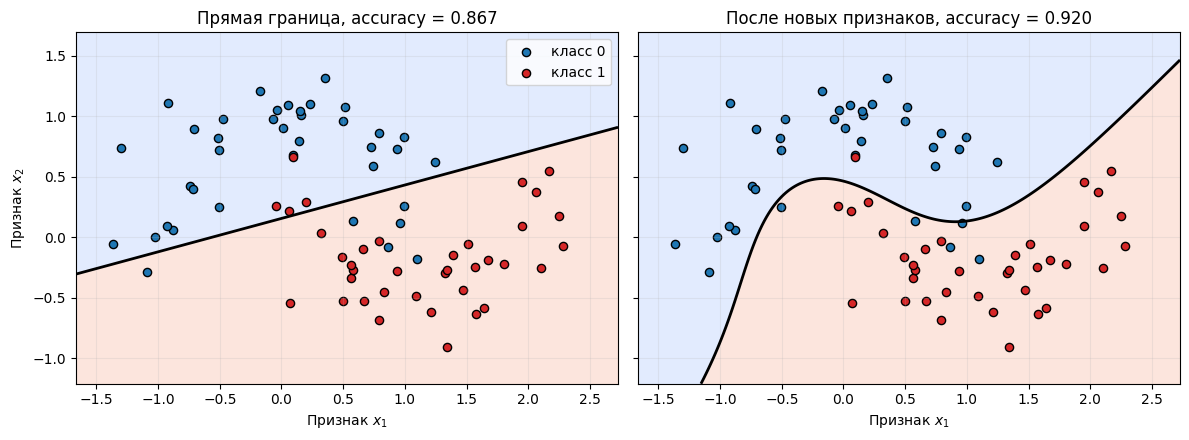

In [27]:
from sklearn.datasets import make_moons
from sklearn.preprocessing import PolynomialFeatures

X_moons, y_moons = make_moons(n_samples=250, noise=0.22, random_state=42)
moon_train, moon_test, ym_train, ym_test = train_test_split(
    X_moons, y_moons, test_size=0.3, random_state=42, stratify=y_moons
)

plain_moon = LogisticRegression().fit(moon_train, ym_train)
poly = PolynomialFeatures(degree=3, include_bias=False)
moon_train_poly = poly.fit_transform(moon_train)
moon_test_poly = poly.transform(moon_test)
curved_moon = LogisticRegression(max_iter=2000).fit(moon_train_poly, ym_train)

print(f'Accuracy с прямой границей: {accuracy_score(ym_test, plain_moon.predict(moon_test)):.3f}')
print(f'Accuracy с новыми признаками: {accuracy_score(ym_test, curved_moon.predict(moon_test_poly)):.3f}')

# Нарисуем обе границы на одной и той же сетке.
mx1 = np.linspace(X_moons[:, 0].min() - 0.3, X_moons[:, 0].max() + 0.3, 250)
mx2 = np.linspace(X_moons[:, 1].min() - 0.3, X_moons[:, 1].max() + 0.3, 250)
mxx1, mxx2 = np.meshgrid(mx1, mx2)
moon_grid = np.column_stack([mxx1.ravel(), mxx2.ravel()])
plain_surface = plain_moon.predict_proba(moon_grid)[:, 1].reshape(mxx1.shape)
curved_surface = curved_moon.predict_proba(poly.transform(moon_grid))[:, 1].reshape(mxx1.shape)

acc_plain = accuracy_score(ym_test, plain_moon.predict(moon_test))
acc_curved = accuracy_score(ym_test, curved_moon.predict(moon_test_poly))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharex=True, sharey=True)
for ax, surface, title in [
    (axes[0], plain_surface, f'Прямая граница, accuracy = {acc_plain:.3f}'),
    (axes[1], curved_surface, f'После новых признаков, accuracy = {acc_curved:.3f}'),
]:
    ax.contourf(mxx1, mxx2, surface, levels=[0, 0.5, 1], cmap='coolwarm', alpha=0.25)
    ax.contour(mxx1, mxx2, surface, levels=[0.5], colors='black', linewidths=2)
    for label, colour, name in [(0, 'tab:blue', 'класс 0'), (1, 'tab:red', 'класс 1')]:
        mask = (ym_test == label)
        ax.scatter(moon_test[mask, 0], moon_test[mask, 1],
                   c=colour, edgecolor='black', s=35, label=name)
    ax.set_title(title)
    ax.set_xlabel('Признак $x_1$')
    ax.grid(alpha=0.2)
axes[0].set_ylabel('Признак $x_2$')
axes[0].legend(loc='upper right')
plt.tight_layout(); plt.show()


## 23. Границы, за которые нельзя выходить

**Ограничения интерпретации.** Коэффициенты логистической регрессии читаются удобно, но у такого чтения есть границы:

- коэффициент показывает связь, а не причину: признак может просто идти «в комплекте» с настоящей причиной;
- коэффициент верен только при неизменных остальных признаках, а в жизни признаки часто меняются вместе;
- если признаки сильно связаны между собой, модель может почти произвольно поделить вклад между ними, и знак отдельного коэффициента становится неустойчивым;
- сравнивать коэффициенты друг с другом можно только после приведения признаков к одному масштабу (п. 18);
- одинаковый прирост $z$ по-разному меняет вероятность в середине и у краёв диапазона (п. 17).

**Ограничения экстраполяции.** **Экстраполяция** — это применение модели к таким значениям признаков, которых в обучающих данных не было: за пределами их диапазона. Прогноз внутри диапазона обучающих данных называют **интерполяцией**.

Коэффициенты и вероятности логистической регрессии описывают связь **внутри диапазона обучающих данных**. Наш двумерный пример учился на подготовке примерно от 0 до 10 часов. Формула сигмоиды формально выдаст ответ и для 100 часов — и выдаст его максимально уверенно. Но проверить его не на чем: таких учеников модель не видела, и связь там могла бы вести себя совсем иначе. Посмотрим на это в числах.


Модель видела подготовку от 0.2 до 9.9 часов.

 подготовка  сон  P(сдал)           это
          2  7.0 0.133283  интерполяция
          5  7.0 0.887658  интерполяция
          8  7.0 0.997543  интерполяция
         10  7.0 0.999822 ЭКСТРАПОЛЯЦИЯ
         20  7.0 1.000000 ЭКСТРАПОЛЯЦИЯ
         50  7.0 1.000000 ЭКСТРАПОЛЯЦИЯ
        100  7.0 1.000000 ЭКСТРАПОЛЯЦИЯ


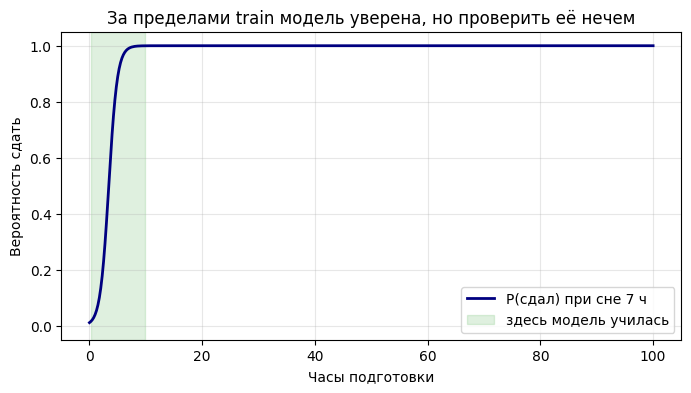


При 100 часах подготовки модель обещает P = 1.000000 — абсолютную уверенность.
Это не знание, а продолжение формулы: ни одного такого ученика в данных не было.


In [28]:
low, high = X_train['подготовка'].min(), X_train['подготовка'].max()
print(f'Модель видела подготовку от {low:.1f} до {high:.1f} часов.\n')

probe = pd.DataFrame({'подготовка': [2, 5, 8, 10, 20, 50, 100], 'сон': 7.0})
probe['P(сдал)'] = model.predict_proba(probe)[:, 1]
probe['это'] = np.where(probe['подготовка'] <= high, 'интерполяция', 'ЭКСТРАПОЛЯЦИЯ')
print(probe.round(6).to_string(index=False))

grid_hours = np.linspace(0, 100, 400)
curve = model.predict_proba(pd.DataFrame({'подготовка': grid_hours, 'сон': 7.0}))[:, 1]

plt.figure(figsize=(8, 4))
plt.plot(grid_hours, curve, color='navy', linewidth=2, label='P(сдал) при сне 7 ч')
plt.axvspan(low, high, color='tab:green', alpha=0.15, label='здесь модель училась')
plt.xlabel('Часы подготовки'); plt.ylabel('Вероятность сдать')
plt.title('За пределами train модель уверена, но проверить её нечем')
plt.ylim(-0.05, 1.05); plt.grid(alpha=0.3); plt.legend(); plt.show()

print('\nПри 100 часах подготовки модель обещает P = 1.000000 — абсолютную уверенность.')
print('Это не знание, а продолжение формулы: ни одного такого ученика в данных не было.')


## 24. Калибровка вероятностей *

Предсказанные вероятности не гарантированно совпадают с частотами событий на новых данных. **Калибровка** (например, isotonic или Platt) выравнивает вероятности по validation. После внедрения качество и калибровку мониторят на свежих данных.

В sklearn калибровку выполняет `CalibratedClassifierCV`, и оба названных способа — это его параметр `method`:

- `method='sigmoid'` — калибровка Платта (Platt scaling): поверх ответов модели подгоняется сигмоида, у неё всего два параметра, поэтому способ устойчив на небольших выборках;
- `method='isotonic'` — изотоническая регрессия: подгоняется произвольная неубывающая ступенчатая функция, она гибче, но на малых выборках легче переобучается.

Калибратор нельзя настраивать на train: там модель уже подогналась под ответы. Поэтому модель, обученную на train, оборачивают в `FrozenEstimator` («заморозить, не переобучать»), а сам калибратор настраивают на validation. Проверяем результат на test: по калибровочной кривой и по **Brier score** (средний квадрат разницы между предсказанной вероятностью и фактом; меньше — лучше).

Калибровка нужна не всегда: если модель и так выдаёт честные вероятности, Brier score после неё не улучшится. Именно это мы и увидим ниже.
Чтобы понять, много это или мало, Brier score всегда сравнивают с чем-то. Наш ориентир — «модель», которая всем подряд называет одну и ту же вероятность, равную доле класса 1 в train. Если наша модель не обгоняет такую константу, вероятности она предсказывать не умеет.

И сразу оговорка про картинку: в test всего 50 объектов, а точек на калибровочной кривой пять — значит, каждая точка посчитана примерно по 10 объектам. Такая кривая сильно скачет, и по ней видно только грубую тенденцию, а не точную картину. На настоящих задачах для калибровочной кривой берут тысячи объектов.

> Небольшая честная оговорка. Мы уже открывали test в разделе 14 и открываем его снова здесь. Правило «один раз» относится к **принятию решений**: нельзя, посмотрев на test, вернуться и поменять модель или порог. Смотреть на уже зафиксированную модель с разных сторон — метрики, кривые, калибровка — можно, если по итогам этого мы ничего не переделываем. Именно так мы и поступим: ниже мы только смотрим и ничего не меняем.


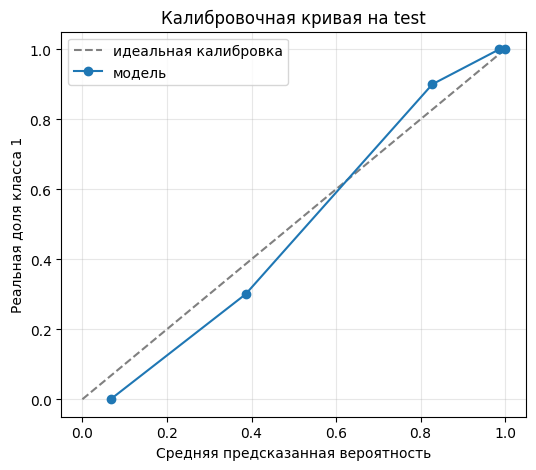

Brier score модели:    0.041 (меньше — лучше)
Brier score константы: 0.230 (всем подряд говорим P = 0.64)

Модель в 5.6 раза лучше константы — её вероятности несут информацию.


In [29]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

observed, predicted = calibration_curve(y_test, p_test, n_bins=5, strategy='quantile')
plt.figure(figsize=(6, 5))
plt.plot([0, 1], [0, 1], '--', color='gray', label='идеальная калибровка')
plt.plot(predicted, observed, marker='o', label='модель')
plt.xlabel('Средняя предсказанная вероятность')
plt.ylabel('Реальная доля класса 1')
plt.title('Калибровочная кривая на test')
plt.grid(alpha=0.3); plt.legend(); plt.show()
print(f'Brier score модели:    {brier_score_loss(y_test, p_test):.3f} (меньше — лучше)')
baseline_probability = np.full_like(p_test, y_train.mean())
print(f'Brier score константы: {brier_score_loss(y_test, baseline_probability):.3f} '
      f'(всем подряд говорим P = {y_train.mean():.2f})')
print(f'\nМодель в {brier_score_loss(y_test, baseline_probability) / brier_score_loss(y_test, p_test):.1f} '
      'раза лучше константы — её вероятности несут информацию.')


Brier score на test (меньше — лучше):
  без калибровки  : Brier = 0.041, точек на кривой: 5
  Platt           : Brier = 0.056, точек на кривой: 5
  isotonic        : Brier = 0.042, точек на кривой: 3


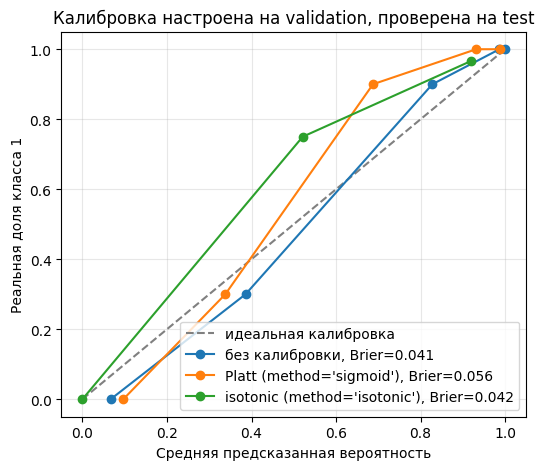

In [30]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.frozen import FrozenEstimator

# Модель уже обучена на train: FrozenEstimator запрещает её переобучать,
# поэтому на validation настраиваются только сами калибраторы.
platt = CalibratedClassifierCV(FrozenEstimator(model), method='sigmoid').fit(X_val, y_val)
isotonic = CalibratedClassifierCV(FrozenEstimator(model), method='isotonic').fit(X_val, y_val)

p_test_platt = platt.predict_proba(X_test)[:, 1]
p_test_isotonic = isotonic.predict_proba(X_test)[:, 1]

print('Brier score на test (меньше — лучше):')
for probabilities, label in [(p_test, 'без калибровки'),
                             (p_test_platt, 'Platt'),
                             (p_test_isotonic, 'isotonic')]:
    observed_c, predicted_c = calibration_curve(y_test, probabilities,
                                                n_bins=5, strategy='quantile')
    print(f'  {label:<16}: Brier = {brier_score_loss(y_test, probabilities):.3f}, '
          f'точек на кривой: {len(observed_c)}')

plt.figure(figsize=(6, 5))
plt.plot([0, 1], [0, 1], '--', color='gray', label='идеальная калибровка')
for probabilities, label in [
    (p_test, 'без калибровки'),
    (p_test_platt, "Platt (method='sigmoid')"),
    (p_test_isotonic, "isotonic (method='isotonic')"),
]:
    observed_c, predicted_c = calibration_curve(y_test, probabilities,
                                                n_bins=5, strategy='quantile')
    plt.plot(predicted_c, observed_c, marker='o',
             label=f'{label}, Brier={brier_score_loss(y_test, probabilities):.3f}')
plt.xlabel('Средняя предсказанная вероятность')
plt.ylabel('Реальная доля класса 1')
plt.title('Калибровка настроена на validation, проверена на test')
plt.grid(alpha=0.3); plt.legend(); plt.show()


Что мы увидели. Brier score после калибровки не улучшился: 0,041 без неё, 0,056 у Platt и 0,042 у изотонической. И это ожидаемо. Логистическая регрессия обучается минимизацией log loss, то есть **сама** стремится выдавать честные вероятности — калибровать здесь почти нечего. А калибратор, настроенный всего на 38 валидационных объектах, добавляет больше шума, чем пользы.

Заметьте ещё одну деталь: у изотонической калибровки на графике всего три точки, а не пять. Изотоническая регрессия — ступенчатая функция, она склеивает многие вероятности в одинаковые значения, и корзины схлопываются. На маленькой выборке это ещё один признак того, что ей не хватает данных.

Вывод: калибровка окупается тогда, когда вероятности модели заметно смещены — например, у деревьев и случайного леса, о которых пойдёт речь дальше в курсе. Для логистической регрессии её обычно не требуется.


## 25. Порядок работы с задачей классификации

1. Определить объект, признаки и положительный класс.
2. Сразу разделить данные на train, validation и test.
3. Построить baseline и изучить доли классов.
4. Обучить модель только на train; метрики и порог — на validation.
5. При необходимости — масштаб, регуляризация, веса классов (fit преобразований только на train).
6. Один раз оценить финальный вариант на test и зафиксировать ограничения.


## Итог занятия

Сегодня научились:
- отличать **классификацию** от регрессии и переводить линейную комбинацию признаков в вероятность через **сигмоиду**;
- получать класс только после выбора **порога** и пользоваться `predict` / `predict_proba`;
- читать **матрицу ошибок** и выбирать метрику из цены FP и FN; не доверять одной accuracy при дисбалансе;
- настраивать порог, **`C`**, масштабирование и веса классов на **validation**;
- видеть, когда линейной границы мало, и **один раз** проверять финальный вариант на **test**.

**Главная мысль:** логистическая регрессия сначала считает линейную комбинацию, потом вероятность; класс — следствие порога. Качество нельзя свести к одной универсальной метрике.
